
--- Load Test Dataset ---
Dataset loaded: 14138 samples, 28 features, 2 classes.
Loaded object from ft_transformer_best-2.pt is a state_dict/checkpoint. Instantiating FTTransformer.
Model ready on device: cuda
Test dataset prepared with 14138 samples for batch processing.

--- Performing Inference ---

--- Evaluation Metrics ---
Accuracy:  0.7482
Precision: 0.7237
Recall:    0.8029
F1-Score:  0.7613
Confusion matrix:
[[4902 2167]
 [1393 5676]]
ROC AUC: 0.8225
PR AUC:  0.7948


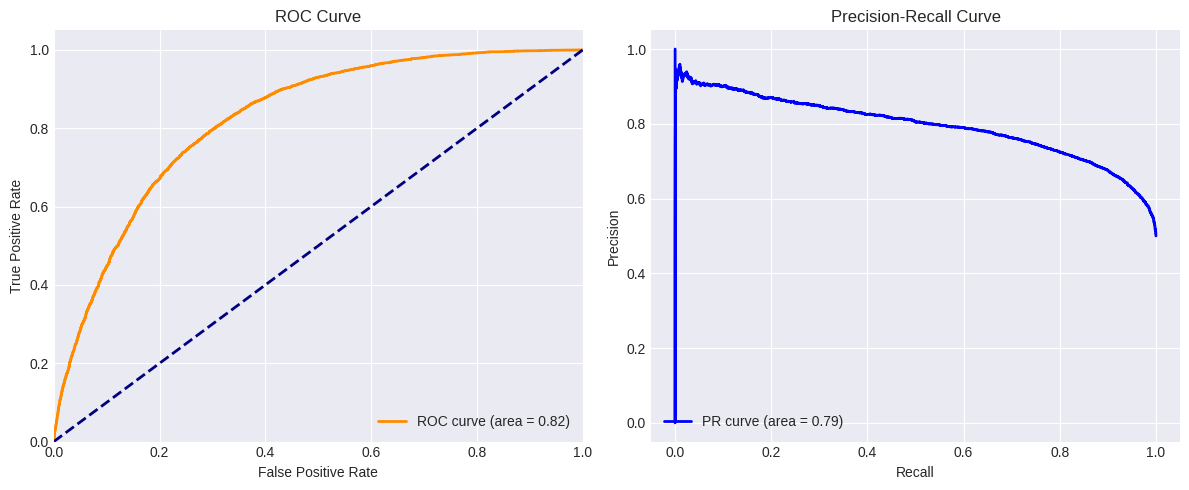

In [ ]:

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import collections

# --- Configuration --- #
MODEL_PATH = 'ft_transformer_best-2.pt'  # <-- point this at your CORRECT, final checkpoint
X_TEST_PATH = '/content/X_test_resampled.csv'  # <-- point this at your CORRECT (11,311-sample) test features
Y_TEST_PATH = '/content/y_test_resampled.csv'                # <-- point this at your CORRECT (11,311-sample) test labels
BATCH_SIZE = 32

# --- FT-Transformer Model Definition --- #
class FTTransformer(nn.Module):
    def __init__(self, num_features, d_model=64, n_heads=4, n_layers=6, dropout=0.2):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model

        self.feature_weight = nn.Parameter(torch.randn(num_features, d_model) * 0.02)
        self.feature_bias = nn.Parameter(torch.zeros(num_features, d_model))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1),
        )

    def forward(self, x):
        batch_size = x.size(0)
        tokens = x.unsqueeze(-1) * self.feature_weight + self.feature_bias
        cls = self.cls_token.expand(batch_size, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        encoded = self.encoder(tokens)
        cls_out = self.norm(encoded[:, 0, :])
        logit = self.head(cls_out).squeeze(-1)
        return logit


# --- 1. Load the test dataset --- #
print("\n--- Load Test Dataset ---")

df_X_test = pd.read_csv(X_TEST_PATH)
X_test = torch.tensor(df_X_test.values, dtype=torch.float32)

df_y_test = pd.read_csv(Y_TEST_PATH)
y_test = torch.tensor(df_y_test.values.flatten(), dtype=torch.long)

if X_test is None or y_test is None:
    raise ValueError("X_test/y_test failed to load.")

num_features = X_test.shape[1]
num_classes = len(torch.unique(y_test))

print(f"Dataset loaded: {len(X_test)} samples, {num_features} features, {num_classes} classes.")
# Sanity check against your known-good split size
if len(X_test) != 11311:
    print(f"WARNING: expected 11311 samples (your validated balanced test split), got {len(X_test)}. "
          f"Double-check X_TEST_PATH / Y_TEST_PATH point at the correct files.")

# --- 2. Load the trained model --- #
model = None
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    loaded_object = torch.load(MODEL_PATH, map_location=torch.device('cpu'))

    if isinstance(loaded_object, torch.nn.Module):
        model = loaded_object
        print(f"Full model loaded successfully from {MODEL_PATH}")
    elif isinstance(loaded_object, (collections.OrderedDict, dict)):
        print(f"Loaded object from {MODEL_PATH} is a state_dict/checkpoint. Instantiating FTTransformer.")
        # Confirmed matching your actual trained config: d_model=64, n_heads=4, n_layers=6, dropout=0.2
        model = FTTransformer(num_features=num_features, d_model=64, n_heads=4, n_layers=6, dropout=0.2)

        if isinstance(loaded_object, dict) and 'state_dict' in loaded_object:
            model.load_state_dict(loaded_object['state_dict'])
        else:
            model.load_state_dict(loaded_object)
    else:
        raise TypeError(f"Unexpected type of loaded object: {type(loaded_object)}.")

    model.eval()
    model.to(device)

except Exception as e:
    print(f"An error occurred during model loading: {e}")
    raise

if model is None:
    raise RuntimeError("Model could not be loaded or instantiated.")

print(f"Model ready on device: {device}")

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Test dataset prepared with {len(test_dataset)} samples for batch processing.")

# --- 3. Perform inference --- #
all_preds = []
all_true_labels = []
all_probs = []

print("\n--- Performing Inference ---")
with torch.no_grad():
    for inputs, labels in test_dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)  # single logit per sample, shape (batch,)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).long()

        all_probs.extend(probs.squeeze().cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_true_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_true_labels = np.array(all_true_labels)
all_probs = np.array(all_probs)

# --- 4. Metrics (FIXED: binary averaging, not weighted) --- #
print("\n--- Evaluation Metrics ---")

accuracy = accuracy_score(all_true_labels, all_preds)
precision = precision_score(all_true_labels, all_preds, average='binary', zero_division=0)
recall = recall_score(all_true_labels, all_preds, average='binary', zero_division=0)
f1 = f1_score(all_true_labels, all_preds, average='binary', zero_division=0)
cm = confusion_matrix(all_true_labels, all_preds)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Confusion matrix:\n{cm}")

# --- 5. ROC / PR curves --- #
fpr, tpr, _ = roc_curve(all_true_labels, all_probs)
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.4f}")

precision_curve, recall_curve, _ = precision_recall_curve(all_true_labels, all_probs)
pr_auc = auc(recall_curve, precision_curve)
print(f"PR AUC:  {pr_auc:.4f}")

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")

plt.subplot(1, 2, 2)
plt.plot(recall_curve, precision_curve, color='blue', lw=2, label=f'PR curve (area = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
import os

# List of files we want to download
files_to_download = [
    'ft_transformer_best.pt'
]

for file_name in files_to_download:
    path = f'/content/{file_name}'
    if os.path.exists(path):
        print(f"Downloading {file_name}...")
        files.download(path)
    else:
        print(f"[WARNING] {file_name} was not found at {path}")